# Premium Positioning Viability Predictor for Coimbatore Restaurants

Business Analytics, individual case study. Rishiikesh S K, CB.SC.U4CSE23236, CSE-C

On Google Maps, a rating of 4.2 stars or more is treated here as the entry ticket to premium positioning.
This notebook looks at which things a restaurant owner controls (Google profile, services, amenities,
price, opening hours, type of restaurant) go with reaching that rating, and how well it can be predicted.

Objectives
1. Collect a dataset of Coimbatore food venues by scraping Google Maps.
2. Predict whether a venue reaches 4.2 stars using attributes that do not leak the rating, comparing
   Logistic Regression, Decision Tree and KNN (plus a Random Forest) on Accuracy, F1 and ROC-AUC.
3. Measure the effect of each factor and turn it into recommendations.

The data was collected once and is observational, so every effect below is an association, not proof of cause.

In [1]:
import json, os, re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter, PercentFormatter
from scipy import stats
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_val_score,
                                     cross_validate, train_test_split)
from sklearn.neighbors import BallTree, KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
%matplotlib inline

SEED = 42
THRESHOLD = 4.2        # premium-positioning benchmark (target)
MIN_REVIEWS = 10       # reliability filter for the rating
CENTRE = (10.9946, 76.9614)   # Coimbatore Town Hall (city centre)
RESULTS = {}           # numbers used in the report are collected here

# chart colours and style
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
RED, NEUTRAL = "#e34948", "#bdbcb6"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK2, "axes.edgecolor": NEUTRAL, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "legend.frameon": False, "axes.prop_cycle": matplotlib.cycler(color=[BLUE, ORANGE, AQUA, YELLOW]),
})

def save(fig, name):
    plt.show()

print("python:", sys.executable)

python: /home/rishiikesh/Rishiikesh/Sem7/BusinessAnalytics/CaseStudy/.venv/bin/python


## 1. Data collection

| Item | Detail |
|---|---|
| Source | Google Maps public business listings |
| Tool | open-source `gosom/google-maps-scraper` (headless browser, run in Docker) |
| Searches | 20 food keywords x 60 Coimbatore localities = 1,200 searches (`scraping/make_queries.py`) |
| Collected | 22-23 September 2026, 4,917 rows, 4,908 unique places |
| Dataset build | `scraping/build_dataset.py` removes duplicates, keeps food venues inside Coimbatore district and removes personal data (reviewer names and text, owner IDs, phone numbers, e-mails). Output is `data/raw_gmaps_scrape.csv`. |

Google Maps gives only about 120 results per search, so many small keyword + locality searches were run and
merged on Google's `place_id`. A first pilot of 200 listings was collected with the Apify Google Places Crawler,
but its free credit was not enough, so the final data was collected with the open-source scraper. The pilot
is not part of this analysis.

In [2]:
raw = pd.read_csv("data/raw_gmaps_scrape.csv")
print(f"collected dataset: {raw.shape[0]:,} venues x {raw.shape[1]} attributes")
display(raw.drop(columns=["attributes", "open_hours", "maps_url"]).head(3).T)

collected dataset: 4,667 venues x 29 attributes


,0,1,2
place_id,ChIJC8h7AABZqDsRJ9SnKUu2Sc8,ChIJpSpqlBxZqDsRoxsFHp2mNFI,ChIJoVTOCQRZqDsRIs_TVkyuFI4
name,Anu mess,Sri Balaji Homely Mess,Patti Amma Tiffin Stall
google_category,Indian restaurant,South Indian restaurant,South Indian restaurant
concept,Multi-cuisine / General,South Indian & Regional,South Indian & Regional
address,"2X52+H8V Anu mess, R.S. Puram, Coimbatore, Tam...","79, Diwan Bahadur Road, R S Puram West, near I...","96, VCV Rd, VCV Layout, Sukrawar Pettai, R.S. ..."
area,R.S. Puram,R.S. Puram,R.S. Puram
town,Coimbatore,Coimbatore,Coimbatore
pincode,641002.0,641002.0,641002.0
latitude,11.008983,11.008745,11.008216
longitude,76.950802,76.950814,76.957729


In [3]:
summary = pd.DataFrame({
    "type": raw.dtypes.astype(str),
    "non-missing %": (raw.notna().mean() * 100).round(1),
    "example": raw.apply(lambda c: str(c.dropna().iloc[0])[:60] if c.notna().any() else ""),
})
summary

,type,non-missing %,example
place_id,str,100.0,ChIJC8h7AABZqDsRJ9SnKUu2Sc8
name,str,100.0,Anu mess
google_category,str,100.0,Indian restaurant
concept,str,100.0,Multi-cuisine / General
address,str,100.0,"2X52+H8V Anu mess, R.S. Puram, Coimbatore, Tam..."
area,str,99.7,R.S. Puram
town,str,99.7,Coimbatore
pincode,float64,99.4,641002.0
latitude,float64,100.0,11.008983
longitude,float64,100.0,76.950802


## 2. Data preparation

### 2.1 Choosing the venues to model
* Venues without a rating cannot be labelled, so they are dropped.
* Closed venues are dropped.
* Venues with fewer than 10 reviews are dropped. An average of a few reviews is very noisy near a 4.2 cut-off.
  With a rating standard deviation of about 1 star, the standard error with 5 reviews is around 0.45 stars.
  Section 3 shows this in the data.

In [4]:
rated = raw[raw["rating"].notna()]
live = rated[rated["is_closed"] == 0]
sample = live[live["reviews_count"] >= MIN_REVIEWS].copy()
funnel = pd.DataFrame({
    "step": ["Unique places scraped", "Food-service venues in Coimbatore district",
             "... with a rating", "... and not closed", f"... and >= {MIN_REVIEWS} reviews (modelling sample)"],
    "venues": [4908, len(raw), len(rated), len(live), len(sample)],
})
RESULTS["funnel"] = funnel.to_dict("records")
funnel

,step,venues
0,Unique places scraped,4908
1,Food-service venues in Coimbatore district,4667
2,... with a rating,4522
3,... and not closed,4472
4,... and >= 10 reviews (modelling sample),3412


### 2.2 Target variable
`high_rating = 1` if the Google rating is **≥ 4.2**, otherwise 0.

In [5]:
sample["high_rating"] = (sample["rating"] >= THRESHOLD).astype(int)
bal = sample["high_rating"].value_counts()
RESULTS["n_model"] = int(len(sample))
RESULTS["success_rate"] = float(sample["high_rating"].mean())
print(f"modelling sample: {len(sample):,} venues | >= 4.2: {bal[1]:,} ({bal[1]/len(sample):.1%}) | < 4.2: {bal[0]:,} ({bal[0]/len(sample):.1%})")

modelling sample: 3,412 venues | >= 4.2: 2,079 (60.9%) | < 4.2: 1,333 (39.1%)


### 2.3 Feature engineering
Each raw field is turned into a feature the owner could act on. A feature must be known before the rating
and must not be built from it.

| Group | Features | Built from |
|---|---|---|
| Concept | `concept` (8 groups), `is_chain`, `veg_only` | Google category, brand name appearing 3 or more times, "Vegetarian options only" |
| Price | `price_tier`: Budget (up to ₹200), Mid (up to ₹400), Premium (above ₹400), Not disclosed | upper end of the ₹ range |
| Google profile | `is_claimed`, `own_website`, `social_page_only`, `has_phone`, `has_menu_link`, `online_ordering`, `has_attributes` | profile fields |
| Services | `table_service`, `delivery`, `takes_reservations` | "about" attributes and booking links |
| Amenities and payments | `restroom`, `wifi`, `free_parking`, `kid_friendly`, `outdoor_seating`, `wheelchair_access`, `card_payments`, `digital_payments` | "about" attributes marked as enabled |
| Opening hours | `weekly_hours`, `open_late` (closes after 11 pm), `opens_early` (opens before 8 am), `has_hours` | parsed opening hours |
| Location | `dist_centre_km`, `log_density` (log of 1 + other venues within 1 km) | latitude and longitude |
| Control | `log_reviews` = log(1 + review count) | number of reviews |

Left out on purpose:
* the 1 to 5 star counts and review text, because they make up the rating
* Google "Highlights" such as "Great coffee", which come from reviews
* "Popular for", "Crowd" and "Atmosphere", which describe customers rather than something the owner controls

In [6]:
def parse_attributes(v):
    out = {}
    if isinstance(v, str):
        for section in json.loads(v):
            for opt in section.get("options") or []:
                out[f"{section['name']}/{opt['name']}"] = bool(opt.get("enabled"))
    return out

def _minutes(t, meridiem):
    m = re.match(r"(\d{1,2})(?::(\d{2}))?\s*(am|pm)?", t.strip().lower())
    h, mi, ap = int(m.group(1)), int(m.group(2) or 0), m.group(3) or meridiem
    if ap == "pm" and h != 12: h += 12
    if ap == "am" and h == 12: h = 0
    return h * 60 + mi

def parse_hours(v):
    # returns weekly hours, opens before 8 am, closes after 11 pm
    if not isinstance(v, str):
        return np.nan, np.nan, np.nan
    total, early, late = 0, 0, 0
    for spans in json.loads(v).values():
        for s in spans:
            s = s.replace(" ", " ").strip().lower()
            if "24 hours" in s:
                total, early, late = total + 1440, 1, 1
                continue
            parts = re.split(r"[–-]", s)
            if "closed" in s or len(parts) != 2:
                continue
            end_ap = (re.search(r"(am|pm)", parts[1]) or [None])[0]
            start_ap = (re.search(r"(am|pm)", parts[0]) or [None])[0]
            end, start = _minutes(parts[1], end_ap), _minutes(parts[0], start_ap or end_ap)
            if start_ap is None and start > end:
                start -= 720                      # "11-3 pm" means 11 am - 3 pm
            if end <= start:
                end += 1440                       # closes after midnight
            total += end - start
            early |= start < 8 * 60
            late |= end > 23 * 60
    return total / 60, early, late

# quick checks on the time formats found in the data
for text, expected in {"4:30 am–10 pm": 17.5, "12–10 pm": 10, "11–3 pm": 4, "7 pm–2 am": 7,
                       "Open 24 hours": 24, "6:30–11 pm": 4.5}.items():
    assert parse_hours(json.dumps({"Mon": [text.replace(" am", " am").replace(" pm", " pm")]}))[0] == expected, text

def price_tier(s):
    if pd.isna(s):
        return "Not disclosed"
    nums = [int(x.replace(",", "")) for x in re.findall(r"\d[\d,]*", s)]
    upper = nums[-1] if len(nums) > 1 else nums[0] * 2
    return "Budget" if upper <= 200 else "Mid" if upper <= 400 else "Premium"

def brand(name):
    s = re.split(r"\s[-–|@]\s|\(|,|\|", str(name).lower())[0]
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    s = re.sub(r"\b(restaurant|restaurants|hotel|the|pvt|ltd)\b", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def haversine_km(lat, lng, lat0, lng0):
    lat, lng, lat0, lng0 = map(np.radians, (lat, lng, lat0, lng0))
    a = np.sin((lat - lat0) / 2) ** 2 + np.cos(lat) * np.cos(lat0) * np.sin((lng - lng0) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

In [7]:
brand_counts = raw["name"].apply(brand).value_counts()
all_live = raw[raw["is_closed"] == 0]
venue_tree = BallTree(np.radians(all_live[["latitude", "longitude"]].values), metric="haversine")

def engineer(df):
    g = df.copy()
    A = g["attributes"].apply(parse_attributes)
    on = lambda *keys: A.apply(lambda d: int(any(d.get(k, False) for k in keys)))
    # concept
    b = g["name"].apply(brand)
    g["is_chain"] = (b.map(brand_counts).ge(3) & b.str.len().ge(4)).astype(int)
    g["veg_only"] = on("Offerings/Vegetarian options only")
    # pricing
    g["price_tier"] = g["price_range"].apply(price_tier)
    # digital profile
    site = g["website"].fillna("")
    social = site.str.contains(r"instagram|facebook|wa\.me|linktr|youtube", case=False)
    g["own_website"] = (site.ne("") & ~social).astype(int)
    g["social_page_only"] = social.astype(int)
    g["has_menu_link"] = g["menu_link"].notna().astype(int)
    g["online_ordering"] = g["online_order_partners"].notna().astype(int)
    g["has_attributes"] = g["attributes"].notna().astype(int)
    # service model
    g["table_service"] = on("Dining options/Table service")
    g["delivery"] = on("Service options/Delivery", "Service options/No-contact delivery")
    g["takes_reservations"] = (on("Planning/Accepts reservations").astype(bool) | g["reservation_partners"].notna()).astype(int)
    # amenities & payments
    g["restroom"] = on("Amenities/Restroom")
    g["wifi"] = on("Amenities/Wi-Fi")
    g["free_parking"] = on("Parking/Free parking lot", "Parking/Free street parking", "Parking/On-site parking")
    g["kid_friendly"] = on("Children/Good for kids", "Children/High chairs", "Children/Kids' menu")
    g["outdoor_seating"] = on("Service options/Outdoor seating")
    g["wheelchair_access"] = on("Accessibility/Wheelchair-accessible entrance")
    g["card_payments"] = on("Payments/Credit cards", "Payments/Debit cards")
    g["digital_payments"] = on("Payments/NFC mobile payments", "Payments/Google Pay")
    # operations (missing hours -> median + has_hours flag)
    h = pd.DataFrame(g["open_hours"].apply(parse_hours).tolist(), index=g.index,
                     columns=["weekly_hours", "opens_early", "open_late"])
    g["has_hours"] = h["weekly_hours"].notna().astype(int)
    g["weekly_hours"] = h["weekly_hours"].fillna(h["weekly_hours"].median())
    g["opens_early"] = h["opens_early"].fillna(0).astype(int)
    g["open_late"] = h["open_late"].fillna(0).astype(int)
    # location: distance to centre, competition = other live venues within 1 km
    g["dist_centre_km"] = haversine_km(g["latitude"], g["longitude"], *CENTRE)
    near = venue_tree.query_radius(np.radians(g[["latitude", "longitude"]].values), r=1 / 6371, count_only=True)
    g["log_density"] = np.log1p(near - 1)
    # control and target
    g["log_reviews"] = np.log1p(g["reviews_count"])
    g["high_rating"] = (g["rating"] >= THRESHOLD).astype(int)
    return g

f = engineer(sample)
print("largest chains:", ", ".join(f.loc[f.is_chain == 1, "name"].apply(brand).value_counts().head(12).index))
print("price tiers:", f["price_tier"].value_counts().to_dict())

largest chains: mario juicy, annapoorna, tea boy, domino s pizza, aroma bakery, fb cakes, martram s south indian coffee house, shree anandhaas sweets and snacks, polar bear ice cream sundaes, shree anandhaas, pizza hut, boomerang ice cream
price tiers: {'Not disclosed': 2178, 'Budget': 698, 'Mid': 368, 'Premium': 168}


In [8]:
CONT = ["log_reviews", "weekly_hours", "dist_centre_km", "log_density"]
BIN = ["is_claimed", "own_website", "social_page_only", "has_phone", "has_menu_link", "online_ordering",
       "has_attributes", "table_service", "delivery", "takes_reservations",
       "restroom", "wifi", "free_parking", "kid_friendly", "outdoor_seating", "wheelchair_access",
       "card_payments", "digital_payments", "open_late", "opens_early", "has_hours", "is_chain", "veg_only"]
CAT = {"concept": "Multi-cuisine / General", "price_tier": "Not disclosed"}   # baseline levels

def design(df):
    parts = [df[CONT + BIN].astype(float)]
    for col, base in CAT.items():
        d = pd.get_dummies(df[col], prefix=col.split("_")[0], prefix_sep=": ").astype(float)
        parts.append(d.drop(columns=f"{col.split('_')[0]}: {base}"))
    return pd.concat(parts, axis=1)

X = design(f)
y = f["high_rating"].astype(int)

# make sure nothing built from the rating is in the features
assert not [c for c in X.columns if re.search(r"rating|star|review_text|highlight", c) and c != "log_reviews"]
print(f"feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns "
      f"({len(CONT)} continuous, {len(BIN)} binary, {X.shape[1]-len(CONT)-len(BIN)} one-hot)")

feature matrix: 3,412 rows x 37 columns (4 continuous, 23 binary, 10 one-hot)


### 2.4 Missing values and multicollinearity

In [9]:
missing = pd.DataFrame({
    "field": ["price_range", "website", "attributes ('about')", "open_hours", "menu_link", "online_order_partners"],
    "missing %": [f[c].isna().mean() * 100 for c in ["price_range", "website", "attributes", "open_hours", "menu_link", "online_order_partners"]],
    "treatment": ["own level 'Not disclosed'", "0 = no website", "0 on every attribute flag + has_attributes flag",
                  "median weekly hours + has_hours flag", "0 = no menu link", "0 = no ordering partner"],
}).round(1)
RESULTS["missing"] = missing.to_dict("records")
display(missing)

Xc = sm.add_constant(X)
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])], index=X.columns).sort_values(ascending=False)
RESULTS["vif_max"] = {"feature": vif.index[0], "vif": float(vif.iloc[0])}
print(f"highest VIF: {vif.index[0]} = {vif.iloc[0]:.2f}  (rule of thumb: < 5 is fine)")
vif.head(8).round(2).to_frame("VIF")

,field,missing %,treatment
0,price_range,63.8,own level 'Not disclosed'
1,website,74.6,0 = no website
2,attributes ('about'),32.6,0 on every attribute flag + has_attributes flag
3,open_hours,10.9,median weekly hours + has_hours flag
4,menu_link,95.3,0 = no menu link
5,online_order_partners,87.4,0 = no ordering partner


highest VIF: takes_reservations = 3.75  (rule of thumb: < 5 is fine)


,VIF
takes_reservations,3.75
free_parking,3.68
online_ordering,3.25
kid_friendly,3.07
digital_payments,3.03
card_payments,2.90
delivery,2.50
table_service,2.35


In [10]:
clean_cols = (["place_id", "name", "area", "town", "latitude", "longitude", "concept", "price_tier",
               "rating", "reviews_count", "high_rating"] + CONT + BIN)
f[clean_cols].to_csv("data/restaurant_clean.csv", index=False)
print(f"saved data/restaurant_clean.csv: {len(f):,} rows x {len(clean_cols)} columns")

saved data/restaurant_clean.csv: 3,412 rows x 38 columns


## 3. Exploratory data analysis

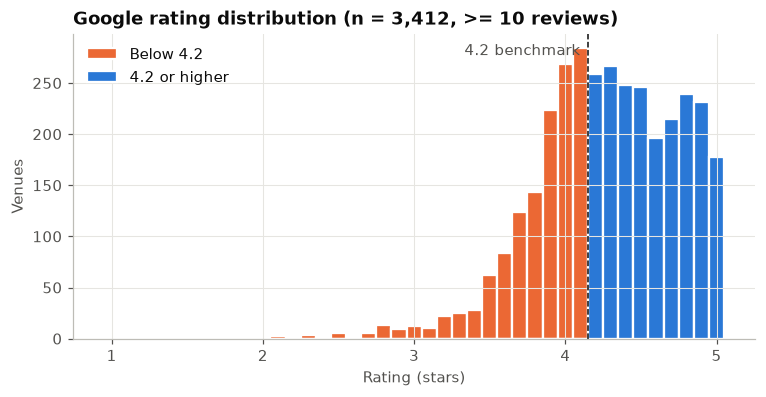

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.6))
bins = np.arange(0.95, 5.06, 0.1)
ax.hist(f.loc[f.rating < THRESHOLD, "rating"], bins=bins, color=ORANGE, edgecolor="white", linewidth=1.5, label="Below 4.2")
ax.hist(f.loc[f.rating >= THRESHOLD, "rating"], bins=bins, color=BLUE, edgecolor="white", linewidth=1.5, label="4.2 or higher")
ax.axvline(THRESHOLD - 0.05, color=INK, lw=1, ls="--")
ax.text(THRESHOLD - 0.1, ax.get_ylim()[1] * 0.93, "4.2 benchmark", ha="right", color=INK2)
ax.set(title=f"Google rating distribution (n = {len(f):,}, >= {MIN_REVIEWS} reviews)", xlabel="Rating (stars)", ylabel="Venues")
ax.legend(loc="upper left")
RESULTS["rating_stats"] = {"mean": float(f.rating.mean()), "median": float(f.rating.median()), "sd": float(f.rating.std())}
save(fig, "01_rating_distribution")

Most ratings are high: the mean is 4.27 and the median is 4.3, with a standard deviation of 0.48. The 4.2 line sits
just below the median, so about 61% of venues reach it. The two classes are a little uneven, so balanced
class weights are used when training.

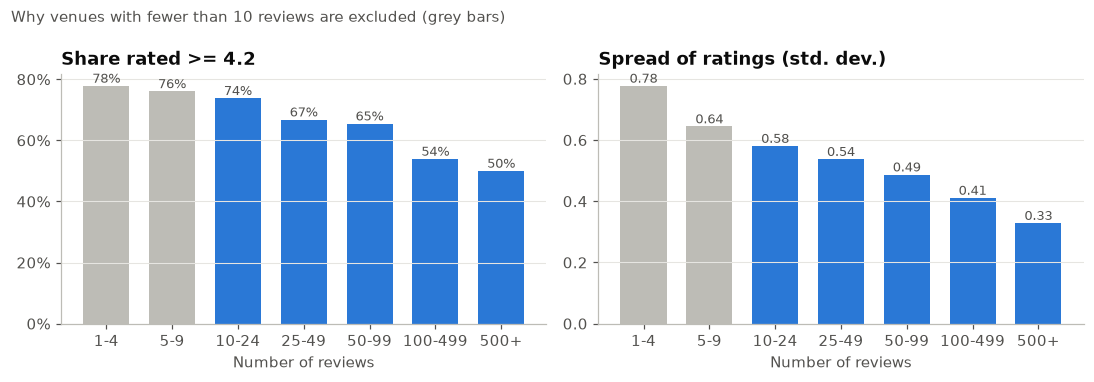

,venues,success,rating_sd
reviews_count,,,
1-4,659,0.778,0.777
5-9,401,0.761,0.645
10-24,737,0.738,0.580
25-49,518,0.668,0.538
50-99,478,0.655,0.487
100-499,929,0.539,0.411
500+,750,0.500,0.329


In [12]:
bands = pd.cut(live["reviews_count"], [0, 4, 9, 24, 49, 99, 499, np.inf],
               labels=["1-4", "5-9", "10-24", "25-49", "50-99", "100-499", "500+"])
rel = live.assign(hit=live["rating"] >= THRESHOLD).groupby(bands, observed=True).agg(
    venues=("hit", "size"), success=("hit", "mean"), rating_sd=("rating", "std"))
RESULTS["reliability"] = rel.reset_index().rename(columns={"reviews_count": "band"}).to_dict("records")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
x = np.arange(len(rel))
for ax, col, title, fmt in [(axes[0], "success", "Share rated >= 4.2", "{:.0%}"),
                            (axes[1], "rating_sd", "Spread of ratings (std. dev.)", "{:.2f}")]:
    colors = [NEUTRAL if i < 2 else BLUE for i in range(len(rel))]
    ax.bar(x, rel[col], color=colors, width=0.7)
    for i, v in enumerate(rel[col]):
        ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=8.5, color=INK2)
    ax.set_xticks(x, rel.index, rotation=0)
    ax.set(title=title, xlabel="Number of reviews")
    ax.grid(axis="x", visible=False)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
fig.suptitle("Why venues with fewer than 10 reviews are excluded (grey bars)", x=0.01, ha="left", fontsize=10, color=INK2)
fig.tight_layout()
save(fig, "02_rating_reliability")
rel.round(3)

Venues with very few reviews look better than they probably are. 78% of venues with 1 to 4 reviews are rated 4.2 or
higher, against 50% of venues with 500 or more, and the spread of ratings falls from 0.78 to 0.33 stars. A few
friendly early reviews can push a new place above 4.2 by chance. This is why venues with fewer than 10
reviews are dropped and the review count is kept in the model as a control.

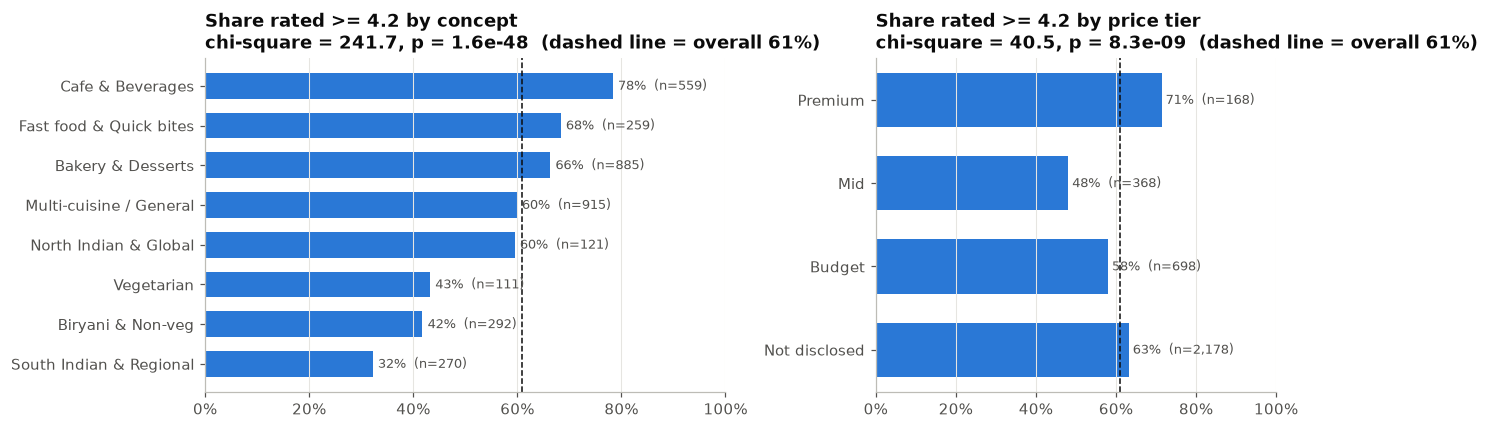

In [13]:
def rate_bar(ax, col, title, order=None):
    g = f.groupby(col)["high_rating"].agg(["mean", "size"])
    g = g.loc[order] if order else g.sort_values("mean")
    ax.barh(g.index, g["mean"], color=BLUE, height=0.65)
    ax.axvline(f.high_rating.mean(), color=INK, lw=1, ls="--")
    for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(m + 0.01, i, f"{m:.0%}  (n={n:,})", va="center", fontsize=8.5, color=INK2)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="y", visible=False)
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(f[col], f["high_rating"]))
    ax.set_title(f"{title}\nchi-square = {chi2:.1f}, p = {p:.1e}  (dashed line = overall {f.high_rating.mean():.0%})")
    return {"chi2": float(chi2), "p": float(p), "rates": g["mean"].round(4).to_dict(), "n": g["size"].to_dict()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.3, 1]})
RESULTS["concept_test"] = rate_bar(axes[0], "concept", "Share rated >= 4.2 by concept")
RESULTS["price_test"] = rate_bar(axes[1], "price_tier", "Share rated >= 4.2 by price tier",
                                 order=["Not disclosed", "Budget", "Mid", "Premium"])
fig.tight_layout()
save(fig, "03_concept_price")

Type of restaurant clearly matters (chi-square 241.7, p < 0.001). Cafés and beverage places reach 4.2 or higher
78% of the time, followed by fast food (68%) and bakeries and desserts (66%). Traditional South Indian (32%),
biryani and non-veg (42%) and vegetarian (43%) restaurants are the lowest. These are busy, value-priced formats
where people compare the food with what they eat at home.

Price matters too (chi-square 40.5, p < 0.001), but not in a straight line. Premium venues (above ₹400) do best at
71% and mid-priced venues (₹200 to 400) do worst at 48%. One possible reason is that mid-priced places are neither
cheap enough to impress nor special enough to justify the price, but this data cannot confirm that.

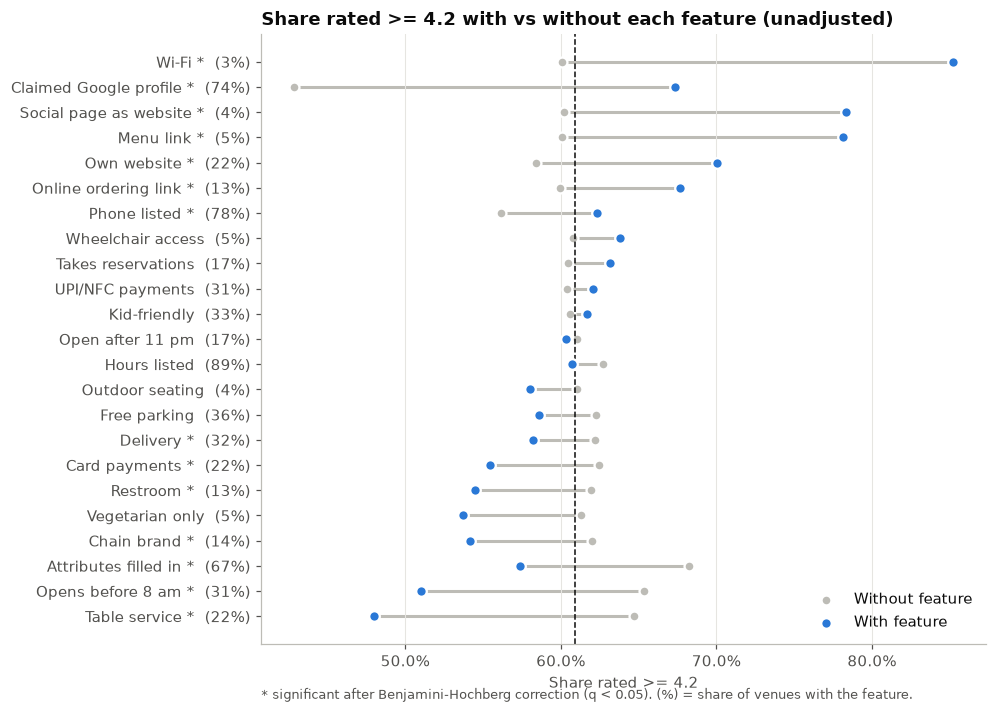

In [14]:
LEVER_LABELS = {
    "is_claimed": "Claimed Google profile", "own_website": "Own website", "social_page_only": "Social page as website",
    "has_phone": "Phone listed", "has_menu_link": "Menu link", "online_ordering": "Online ordering link",
    "has_attributes": "Attributes filled in", "table_service": "Table service", "delivery": "Delivery",
    "takes_reservations": "Takes reservations", "restroom": "Restroom", "wifi": "Wi-Fi",
    "free_parking": "Free parking", "kid_friendly": "Kid-friendly", "outdoor_seating": "Outdoor seating",
    "wheelchair_access": "Wheelchair access", "card_payments": "Card payments", "digital_payments": "UPI/NFC payments",
    "open_late": "Open after 11 pm", "opens_early": "Opens before 8 am", "has_hours": "Hours listed",
    "is_chain": "Chain brand", "veg_only": "Vegetarian only",
    "log_reviews": "Review volume (log)", "weekly_hours": "Weekly open hours", "dist_centre_km": "Distance to centre",
    "log_density": "Nearby competition (log)",
}
rows = []
for c in BIN:
    ct = pd.crosstab(f[c], f["high_rating"])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    rows.append({"feature": c, "label": LEVER_LABELS[c], "prevalence": f[c].mean(),
                 "rate_without": f.loc[f[c] == 0, "high_rating"].mean(),
                 "rate_with": f.loc[f[c] == 1, "high_rating"].mean(), "p": p})
lift = pd.DataFrame(rows)
lift["diff"] = lift["rate_with"] - lift["rate_without"]
lift["p_fdr"] = multipletests(lift["p"], method="fdr_bh")[1]
lift = lift.sort_values("diff").reset_index(drop=True)
RESULTS["lift"] = lift.round(4).to_dict("records")

fig, ax = plt.subplots(figsize=(8.5, 7.2))
for i, r in lift.iterrows():
    ax.plot([r.rate_without, r.rate_with], [i, i], color=NEUTRAL, lw=2, zorder=1)
ax.scatter(lift.rate_without, lift.index, color=NEUTRAL, s=42, zorder=2, label="Without feature", edgecolor="white", linewidth=1.5)
ax.scatter(lift.rate_with, lift.index, color=BLUE, s=48, zorder=3, label="With feature", edgecolor="white", linewidth=1.5)
labels = [f"{r.label}{' *' if r.p_fdr < 0.05 else ''}  ({r.prevalence:.0%})" for r in lift.itertuples()]
ax.set_yticks(lift.index, labels)
ax.axvline(f.high_rating.mean(), color=INK, lw=1, ls="--")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.set(title="Share rated >= 4.2 with vs without each feature (unadjusted)", xlabel="Share rated >= 4.2")
ax.legend(loc="lower right")
ax.text(0, -0.09, "* significant after Benjamini-Hochberg correction (q < 0.05). (%) = share of venues with the feature.",
        transform=ax.transAxes, fontsize=8.5, color=INK2)
save(fig, "04_lever_lift")

This chart is unadjusted, so it does not control for anything else. Among common features the biggest gap is the
claimed Google profile: 67% of claimed venues reach 4.2 against 43% of unclaimed ones, and 74% of venues are
claimed. Having a website, a menu link or online ordering also goes with better ratings. Wi-Fi, a menu link and a
social page as the website show large gaps as well, but only 3 to 5% of venues have them.

Table service, card payments, restrooms and opening before 8 am show negative gaps. These look like signs of
full-service or high-volume places rather than causes of low ratings, and the regression in Section 5 helps to
separate the two.

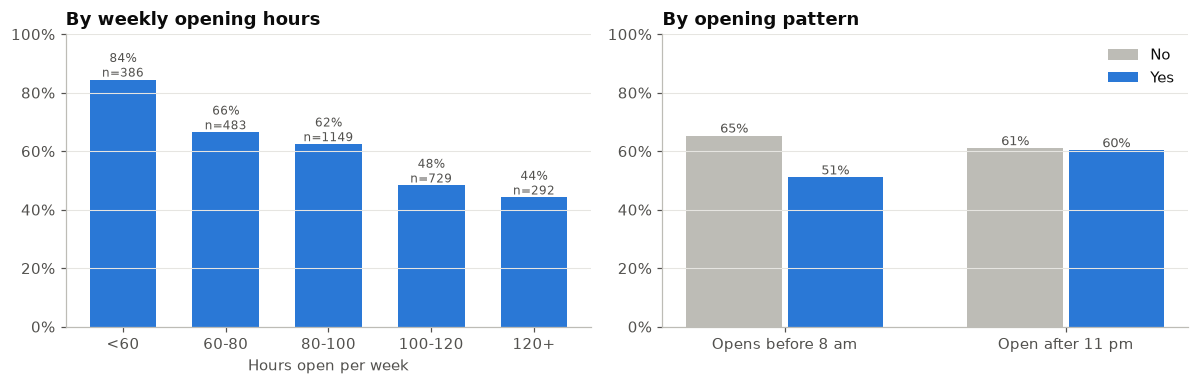

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
hb = pd.cut(f.loc[f.has_hours == 1, "weekly_hours"], [0, 60, 80, 100, 120, 169], labels=["<60", "60-80", "80-100", "100-120", "120+"])
g = f.loc[f.has_hours == 1].groupby(hb, observed=True)["high_rating"].agg(["mean", "size"])
axes[0].bar(g.index.astype(str), g["mean"], color=BLUE, width=0.65)
for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
    axes[0].text(i, m + 0.01, f"{m:.0%}\nn={n}", ha="center", fontsize=8, color=INK2)
axes[0].set(title="By weekly opening hours", xlabel="Hours open per week", ylim=(0, 1))
ops = pd.DataFrame({k: f.groupby(k)["high_rating"].mean() for k in ["opens_early", "open_late"]}).T
ops.index = ["Opens before 8 am", "Open after 11 pm"]
xx = np.arange(2)
axes[1].bar(xx - 0.18, ops[0], 0.34, color=NEUTRAL, label="No")
axes[1].bar(xx + 0.18, ops[1], 0.34, color=BLUE, label="Yes")
for i in range(2):
    for dx, v in [(-0.18, ops.iloc[i, 0]), (0.18, ops.iloc[i, 1])]:
        axes[1].text(i + dx, v + 0.01, f"{v:.0%}", ha="center", fontsize=8.5, color=INK2)
axes[1].set_xticks(xx, ops.index)
axes[1].set(title="By opening pattern", ylim=(0, 1))
axes[1].legend(loc="upper right")
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.grid(axis="x", visible=False)
fig.tight_layout()
RESULTS["hours"] = {"by_band": g["mean"].round(4).to_dict(), "ops": ops.round(4).to_dict()}
save(fig, "05_opening_hours")

Venues that are open fewer hours do better. 84% of venues open under 60 hours a week reach 4.2, compared with 44%
of those open 120 hours or more (tea shops, messes and 24-hour outlets).

Opening before 8 am looks negative on its own (51% against 65%), but once total hours are held fixed in the model,
both early and late opening turn out positive (Section 5). So it seems to be long, stretched-out days that hurt,
not serving breakfast or late-night customers.

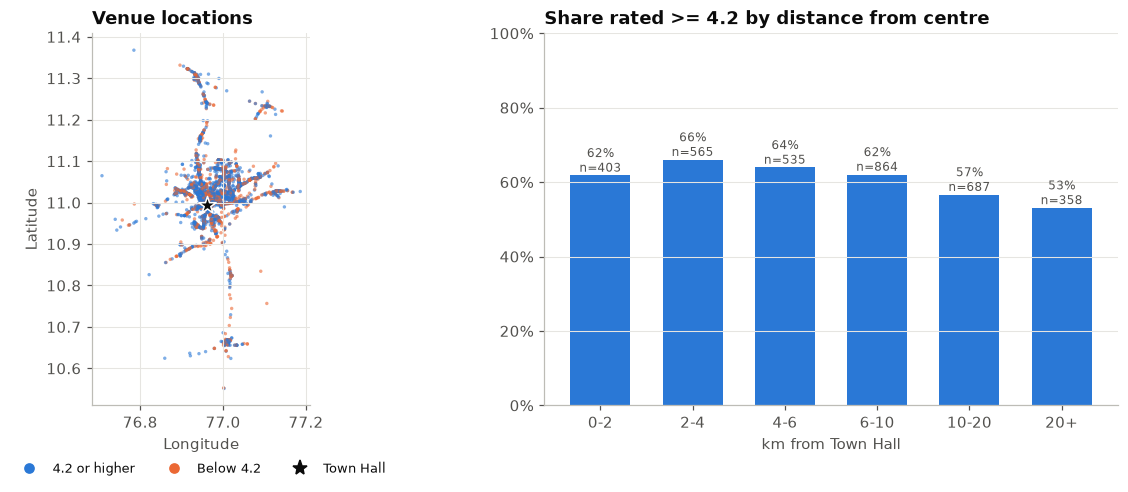

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
shuffled = f.sample(frac=1, random_state=SEED)          # shuffled so one colour does not cover the other
axes[0].scatter(shuffled.longitude, shuffled.latitude, s=5, linewidths=0, alpha=0.6,
                c=np.where(shuffled.high_rating == 1, BLUE, ORANGE))
axes[0].scatter(*CENTRE[::-1], marker="*", s=140, color=INK, zorder=3, edgecolor="white")
axes[0].set(title="Venue locations", xlabel="Longitude", ylabel="Latitude")
axes[0].set_aspect("equal")
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([], [], ls="", marker="o", color=BLUE, label="4.2 or higher"),
                        Line2D([], [], ls="", marker="o", color=ORANGE, label="Below 4.2"),
                        Line2D([], [], ls="", marker="*", color=INK, markersize=10, label="Town Hall")],
               loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8.5)
db = pd.cut(f.dist_centre_km, [0, 2, 4, 6, 10, 20, 60], labels=["0-2", "2-4", "4-6", "6-10", "10-20", "20+"])
g = f.groupby(db, observed=True)["high_rating"].agg(["mean", "size"])
axes[1].bar(g.index.astype(str), g["mean"], color=BLUE, width=0.65)
for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
    axes[1].text(i, m + 0.01, f"{m:.0%}\nn={n}", ha="center", fontsize=8, color=INK2)
axes[1].set(title="Share rated >= 4.2 by distance from centre", xlabel="km from Town Hall", ylim=(0, 1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1)); axes[1].grid(axis="x", visible=False)
fig.tight_layout()
RESULTS["distance"] = g["mean"].round(4).to_dict()
save(fig, "06_geography")

The venues cover Coimbatore city and district towns such as Pollachi, Mettupalayam and Sulur. The share reaching
4.2 is highest 2 to 4 km from the centre (66%) and lower in outer areas (53% beyond 20 km). Distance has only a
small effect in the full model (odds ratio 0.91 per standard deviation).

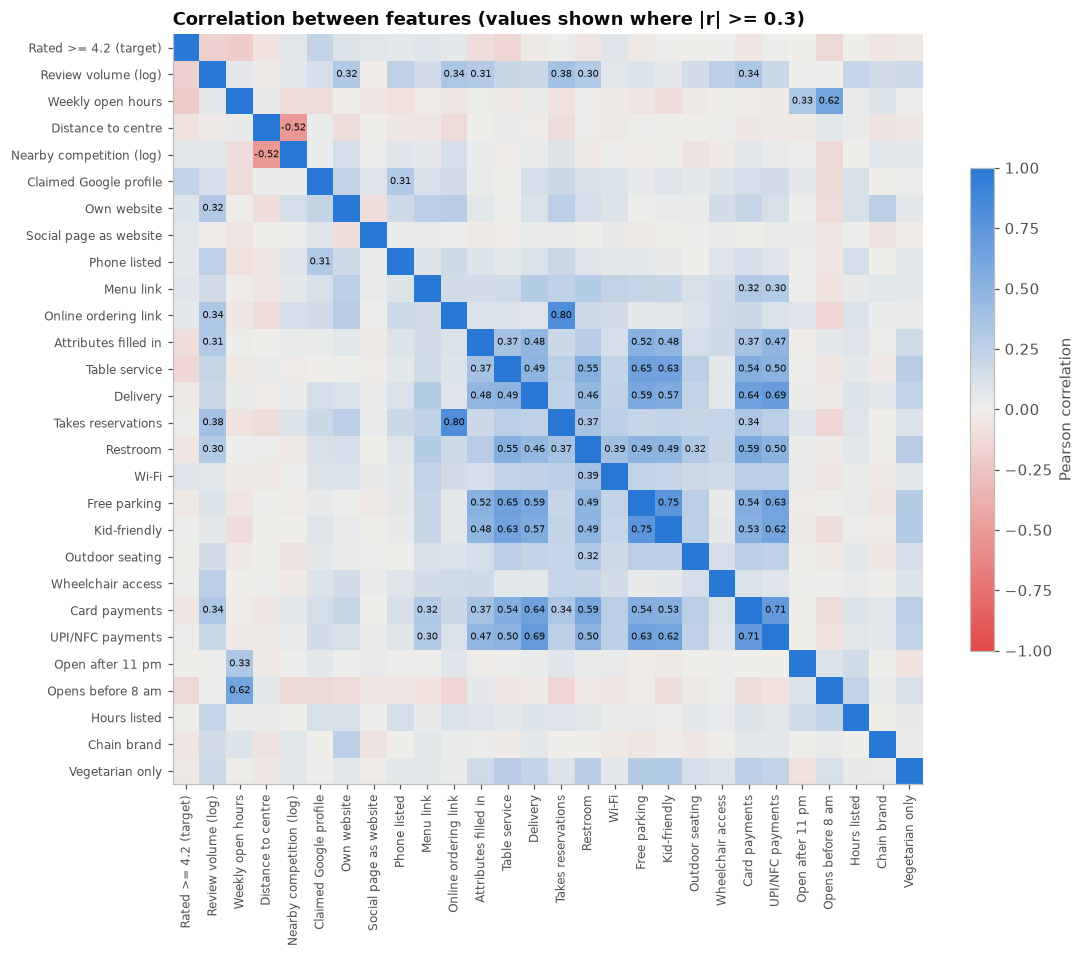

,r with target
weekly_hours,-0.211
log_reviews,-0.173
table_service,-0.143
opens_early,-0.135
has_attributes,-0.104
social_page_only,0.072
has_menu_link,0.078
wifi,0.093
own_website,0.098
is_claimed,0.220


In [17]:
corr_cols = ["high_rating"] + CONT + BIN
C = f[corr_cols].astype(float).corr()
from matplotlib.colors import LinearSegmentedColormap
div = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(C, cmap=div, vmin=-1, vmax=1)
names = ["Rated >= 4.2 (target)"] + [LEVER_LABELS[c] for c in CONT + BIN]
ax.set_xticks(range(len(names)), names, rotation=90, fontsize=8)
ax.set_yticks(range(len(names)), names, fontsize=8)
ax.grid(False)
for i in range(len(C)):
    for j in range(len(C)):
        if i != j and abs(C.iat[i, j]) >= 0.3:
            ax.text(j, i, f"{C.iat[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color=INK)
fig.colorbar(im, ax=ax, shrink=0.6, label="Pearson correlation")
ax.set_title("Correlation between features (values shown where |r| >= 0.3)")
save(fig, "07_correlation")
top = C["high_rating"].drop("high_rating").sort_values()
RESULTS["corr_target"] = top.round(4).to_dict()
pd.concat([top.head(5), top.tail(5)]).round(3).to_frame("r with target")

No single feature is strongly correlated with the target. The largest are the claimed profile (r = +0.22), weekly
hours (-0.21) and review volume (-0.17). Success depends on many small factors together, so a model with all of
them is needed. The features are only moderately correlated with each other (all VIFs are below 4), so each
coefficient can be estimated on its own.

## 4. Predictive modelling

Logistic Regression, Decision Tree and K-Nearest Neighbours are compared on Accuracy, F1 and
ROC-AUC. A Random Forest is added to see how much a more flexible model gains.
* Logistic Regression gives odds ratios that are easy to read.
* Decision Tree gives simple if-then rules.
* KNN is a distance-based model that assumes nothing about the shape of the relationship.

How the models are trained and compared
* Stratified 80/20 train/test split.
* Grid search on the training set with 5-fold stratified cross-validation, scored by ROC-AUC. Scaling is done
  inside the pipeline, so the test data is not used to fit it.
* `class_weight="balanced"` for the 61/39 class split.
* 5-fold cross-validation on the full sample to check stability.
* The best model is the one with the highest cross-validated ROC-AUC. If Logistic Regression is within 0.01 of
  it, Logistic Regression is chosen because it can be interpreted.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
scale = ColumnTransformer([("num", StandardScaler(), CONT)], remainder="passthrough")
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

candidates = {
    "Logistic Regression": (Pipeline([("scale", scale), ("clf", LogisticRegression(class_weight="balanced", max_iter=5000))]),
                            {"clf__C": [0.01, 0.1, 1, 10]}),
    "Decision Tree": (Pipeline([("clf", DecisionTreeClassifier(class_weight="balanced", random_state=SEED))]),
                      {"clf__max_depth": [3, 4, 5, 6, 8], "clf__min_samples_leaf": [10, 25, 50]}),
    "KNN": (Pipeline([("scale", scale), ("clf", KNeighborsClassifier())]),
            {"clf__n_neighbors": [5, 11, 21, 31, 51], "clf__weights": ["uniform", "distance"]}),
    "Random Forest": (Pipeline([("clf", RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=SEED, n_jobs=-1))]),
                      {"clf__max_depth": [6, 10, None], "clf__min_samples_leaf": [5, 10, 20], "clf__max_features": ["sqrt", 0.3]}),
}
best = {}
for name, (pipe, grid) in candidates.items():
    gs = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv5, n_jobs=-1).fit(X_train, y_train)
    best[name] = gs.best_estimator_
    print(f"{name:20s} best CV ROC-AUC (train) = {gs.best_score_:.3f}   params = {gs.best_params_}")
RESULTS["best_params"] = {n: {k.replace('clf__', ''): (v if not isinstance(v, float) else round(v, 3)) for k, v in m.get_params().items()
                              if k.startswith("clf__") and k.replace("clf__", "") in
                              {"C", "max_depth", "min_samples_leaf", "n_neighbors", "weights", "max_features"}}
                          for n, m in best.items()}

Logistic Regression  best CV ROC-AUC (train) = 0.768   params = {'clf__C': 0.1}


Decision Tree        best CV ROC-AUC (train) = 0.729   params = {'clf__max_depth': 8, 'clf__min_samples_leaf': 50}


KNN                  best CV ROC-AUC (train) = 0.759   params = {'clf__n_neighbors': 51, 'clf__weights': 'distance'}


Random Forest        best CV ROC-AUC (train) = 0.779   params = {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5}


In [19]:
def metrics(y_true, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    return {"Accuracy": accuracy_score(y_true, pred), "Precision": precision_score(y_true, pred),
            "Recall": recall_score(y_true, pred), "F1": f1_score(y_true, pred),
            "ROC-AUC": roc_auc_score(y_true, prob), "PR-AUC": average_precision_score(y_true, prob)}

probs = {n: m.predict_proba(X_test)[:, 1] for n, m in best.items()}
holdout = pd.DataFrame({n: metrics(y_test, p) for n, p in probs.items()}).T
base_acc = max(y_test.mean(), 1 - y_test.mean())
holdout.loc["Majority-class baseline"] = [base_acc, y_test.mean(), 1.0, 2 * y_test.mean() / (1 + y_test.mean()), 0.5, y_test.mean()]
RESULTS["holdout"] = holdout.round(4).to_dict("index")
holdout.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.688,0.788,0.668,0.723,0.759,0.802
Decision Tree,0.666,0.755,0.668,0.709,0.733,0.778
KNN,0.736,0.737,0.882,0.803,0.763,0.795
Random Forest,0.726,0.794,0.743,0.768,0.784,0.814
Majority-class baseline,0.609,0.609,1.000,0.757,0.500,0.609


In [20]:
scoring = {"Accuracy": "accuracy", "Precision": "precision", "Recall": "recall", "F1": "f1", "ROC-AUC": "roc_auc"}
cv_rows = {}
for name, model in best.items():
    s = cross_validate(clone(model), X, y, cv=cv5, scoring=scoring, n_jobs=-1)
    cv_rows[name] = {k: (s[f"test_{k}"].mean(), s[f"test_{k}"].std()) for k in scoring}
cv_table = pd.DataFrame({n: {k: f"{m:.3f} ± {sd:.3f}" for k, (m, sd) in r.items()} for n, r in cv_rows.items()}).T
RESULTS["cv"] = {n: {k: [round(m, 4), round(sd, 4)] for k, (m, sd) in r.items()} for n, r in cv_rows.items()}
auc = {n: r["ROC-AUC"][0] for n, r in cv_rows.items()}
top_model = max(auc, key=auc.get)
champion = "Logistic Regression" if auc[top_model] - auc["Logistic Regression"] <= 0.01 else top_model
RESULTS["champion"] = champion
RESULTS["best_auc_model"] = top_model
print(f"highest CV ROC-AUC: {top_model} ({auc[top_model]:.3f}) -> champion: {champion}")
cv_table

highest CV ROC-AUC: Random Forest (0.783) -> champion: Random Forest


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.703 ± 0.025,0.781 ± 0.026,0.713 ± 0.017,0.745 ± 0.020,0.768 ± 0.030
Decision Tree,0.664 ± 0.021,0.749 ± 0.016,0.673 ± 0.025,0.709 ± 0.021,0.718 ± 0.024
KNN,0.715 ± 0.022,0.723 ± 0.015,0.863 ± 0.020,0.787 ± 0.017,0.760 ± 0.028
Random Forest,0.716 ± 0.028,0.781 ± 0.024,0.741 ± 0.028,0.761 ± 0.024,0.783 ± 0.028


All four models beat the majority-class baseline (accuracy 0.61, ROC-AUC 0.50).

Of the three main models, Logistic Regression ranks venues best (cross-validated ROC-AUC
0.768 ± 0.030) and its precision of 0.78 is the best of the three. KNN has the highest F1 (0.787), but this is
mostly because it predicts "4.2 or higher" for almost every venue (recall 0.86). With 61% positives that inflates
F1, so ROC-AUC is used as the main metric. The Decision Tree is the weakest (0.718).

Random Forest is best overall (0.783). It is 0.015 above Logistic Regression, just over the 0.01 margin used for choosing Logistic Regression, so
it is the best predictor, while Logistic Regression is the model used to explain the factors. Accuracy is about
70 to 72% for all of them. Food quality and service are not in the listing data, so much more should not be expected
from these features.

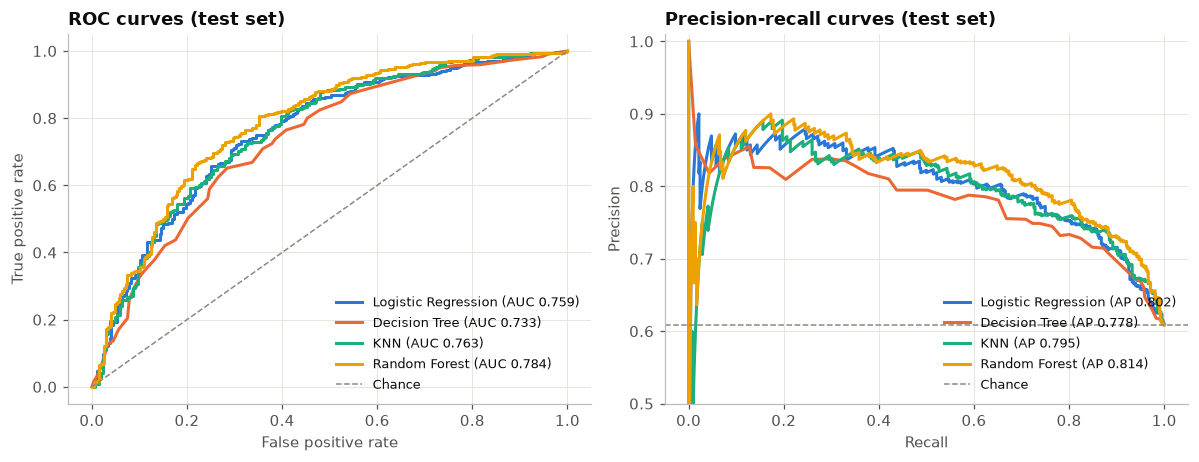

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
colors = {"Logistic Regression": BLUE, "Decision Tree": ORANGE, "KNN": AQUA, "Random Forest": YELLOW}
for n, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=colors[n], lw=2, label=f"{n} (AUC {roc_auc_score(y_test, p):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, color=colors[n], lw=2, label=f"{n} (AP {average_precision_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Chance")
axes[1].axhline(y_test.mean(), color=MUTED, lw=1, ls="--", label="Chance")
axes[0].set(title="ROC curves (test set)", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Precision-recall curves (test set)", xlabel="Recall", ylabel="Precision", ylim=(0.5, 1.01))
for ax in axes: ax.legend(loc="lower right", fontsize=8.5)
fig.tight_layout()
save(fig, "08_roc_pr_curves")

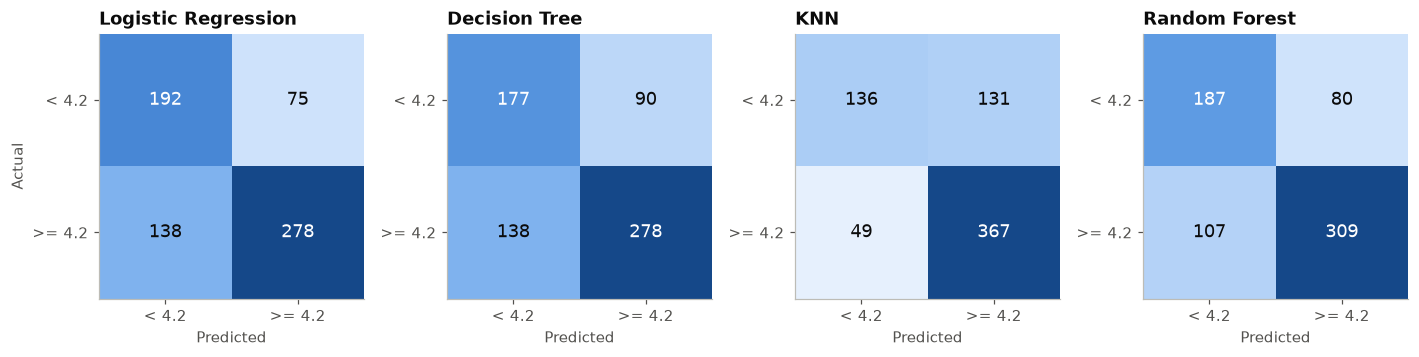

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
from matplotlib.colors import LinearSegmentedColormap
seq = LinearSegmentedColormap.from_list("seq", ["#ffffff", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
for ax, (n, p) in zip(axes, probs.items()):
    cm = confusion_matrix(y_test, (p >= 0.5).astype(int))
    ax.imshow(cm, cmap=seq, vmin=0, vmax=cm.max() * 1.1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=12,
                    color="white" if cm[i, j] > cm.max() * 0.6 else INK)
    ax.set_xticks([0, 1], ["< 4.2", ">= 4.2"]); ax.set_yticks([0, 1], ["< 4.2", ">= 4.2"])
    ax.set(title=n, xlabel="Predicted", ylabel="Actual" if n == "Logistic Regression" else "")
    ax.grid(False)
fig.tight_layout()
save(fig, "09_confusion_matrices")

## 5. Which factors matter
The models above show how well the rating can be predicted. To see which factors matter, four things are used:
1. A logistic regression (statsmodels) on the full sample, giving odds ratios with 95% confidence intervals
   and p-values. Yes/no features compare having it with not having it, and continuous features are per one
   standard deviation.
2. Average marginal effects: the change in the chance of reaching 4.2, in percentage points.
3. Random Forest permutation importance, to check the logistic regression did not miss anything non-linear.
4. A small decision tree with rules that are easy to read.

In [23]:
SD = f[CONT].std()
Xs = X.copy()
Xs[CONT] = (X[CONT] - X[CONT].mean()) / SD
logit = sm.Logit(y, sm.add_constant(Xs)).fit(disp=0, maxiter=500)
ci = logit.conf_int()
coef = pd.DataFrame({"beta": logit.params, "OR": np.exp(logit.params), "OR_low": np.exp(ci[0]),
                     "OR_high": np.exp(ci[1]), "p": logit.pvalues}).drop("const")
coef["label"] = [LEVER_LABELS.get(c, c.replace("concept: ", "Concept: ").replace("price: ", "Price: ")) for c in coef.index]
RESULTS["logit_fit"] = {"pseudo_r2": float(logit.prsquared), "llr_p": float(logit.llr_pvalue), "n": int(logit.nobs),
                        "aic": float(logit.aic)}
RESULTS["odds_ratios"] = coef.round(4).reset_index(names="feature").to_dict("records")
print(f"McFadden pseudo-R2 = {logit.prsquared:.3f} | LR test p = {logit.llr_pvalue:.1e} | n = {int(logit.nobs):,}")
coef.sort_values("OR", ascending=False)[["label", "OR", "OR_low", "OR_high", "p"]].round(3)

McFadden pseudo-R2 = 0.184 | LR test p = 1.1e-152 | n = 3,412


,label,OR,OR_low,OR_high,p
wifi,Wi-Fi,3.606,1.973,6.590,0.000
concept: Cafe & Beverages,Concept: Cafe & Beverages,2.496,1.897,3.285,0.000
is_claimed,Claimed Google profile,2.217,1.825,2.693,0.000
has_menu_link,Menu link,1.858,1.156,2.988,0.011
kid_friendly,Kid-friendly,1.823,1.347,2.468,0.000
concept: Bakery & Desserts,Concept: Bakery & Desserts,1.809,1.414,2.314,0.000
own_website,Own website,1.646,1.301,2.082,0.000
online_ordering,Online ordering link,1.624,1.057,2.498,0.027
social_page_only,Social page as website,1.562,0.976,2.499,0.063
open_late,Open after 11 pm,1.559,1.223,1.986,0.000


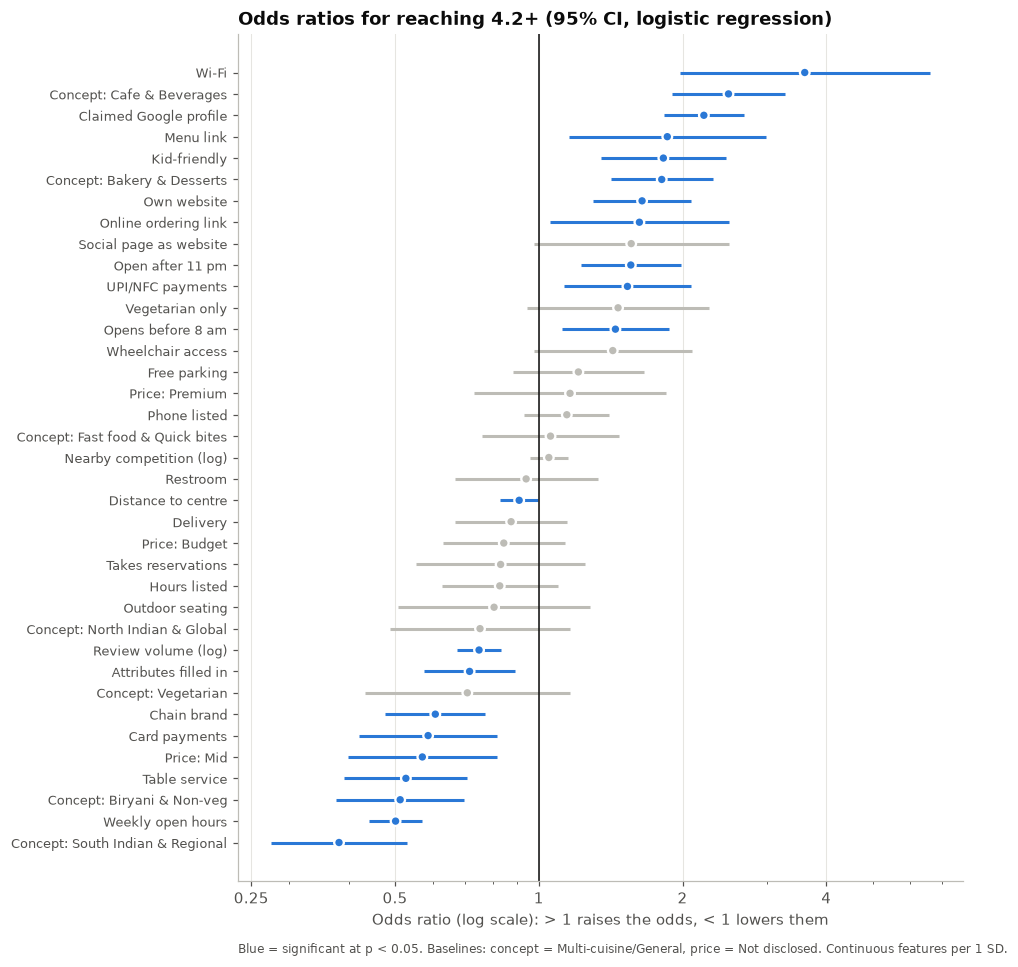

In [24]:
c = coef.sort_values("OR")
fig, ax = plt.subplots(figsize=(8.5, 10))
sig = c["p"] < 0.05
ypos = np.arange(len(c))
ax.hlines(ypos, c["OR_low"], c["OR_high"], color=np.where(sig, BLUE, NEUTRAL), lw=2)
ax.scatter(c["OR"], ypos, color=np.where(sig, BLUE, NEUTRAL), s=40, zorder=3, edgecolor="white", linewidth=1.5)
ax.axvline(1, color=INK, lw=1)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4], ["0.25", "0.5", "1", "2", "4"])
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_yticks(ypos, c["label"], fontsize=8.5)
ax.grid(axis="y", visible=False)
ax.set(title="Odds ratios for reaching 4.2+ (95% CI, logistic regression)",
       xlabel="Odds ratio (log scale): > 1 raises the odds, < 1 lowers them")
ax.text(0, -0.085, "Blue = significant at p < 0.05. Baselines: concept = Multi-cuisine/General, price = Not disclosed. "
        "Continuous features per 1 SD.", transform=ax.transAxes, fontsize=8, color=INK2)
save(fig, "10_odds_ratios")

The logistic regression fits reasonably for this kind of data (McFadden pseudo-R² = 0.18, likelihood-ratio test
p < 10⁻¹⁵⁰). Holding the other features fixed:

* A claimed Google profile multiplies the odds of reaching 4.2 by 2.2, an own website by 1.6, a menu link by 1.9,
  online ordering by 1.6 and UPI/NFC payments by 1.5.
* Wi-Fi has the largest odds ratio (3.6), but only 3% of venues offer it, so its confidence interval is wide.
* Cafés have 2.5 times the odds of the multi-cuisine group and bakeries 1.8 times. South Indian (0.38) and
  biryani/non-veg (0.51) restaurants are lower.
* Chain outlets have 0.61 times the odds of independent ones, possibly because customers expect more from chains.
* More reviews lower the odds (0.75 per standard deviation), possibly because a bigger audience is harder to
  please. Longer weekly hours do too (0.50 per standard deviation).
* Table service, card payments and having the attributes section filled in are also negative. They mostly describe
  formal, full-service restaurants, so this is not a reason to stop accepting cards.
* Among the price tiers only Mid is significant (0.57 compared with venues that do not show a price).

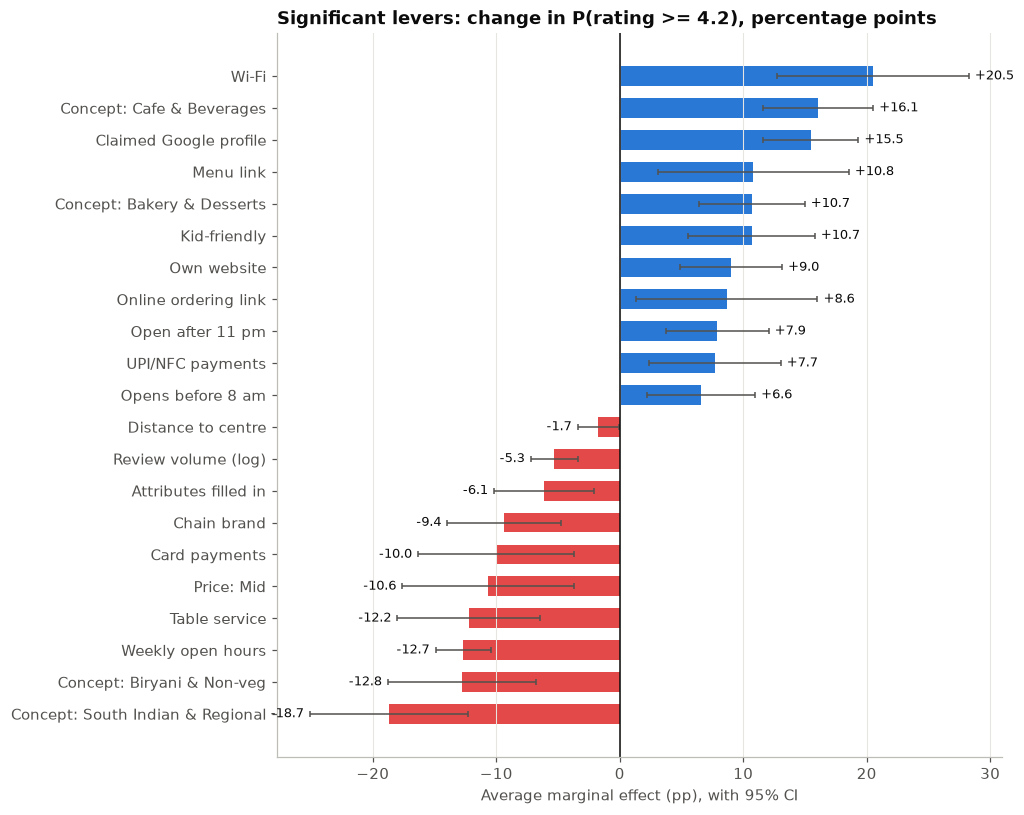

In [25]:
me = logit.get_margeff(at="overall", method="dydx", dummy=True).summary_frame()
me.columns = ["AME", "se", "z", "p", "low", "high"]
me["label"] = coef.loc[me.index, "label"]
me["AME_pp"], me["low_pp"], me["high_pp"] = me["AME"] * 100, me["low"] * 100, me["high"] * 100
RESULTS["marginal_effects"] = me[["label", "AME_pp", "low_pp", "high_pp", "p"]].round(3).reset_index(names="feature").to_dict("records")

m = me[me["p"] < 0.05].sort_values("AME_pp")
fig, ax = plt.subplots(figsize=(8.5, 0.34 * len(m) + 1.4))
ax.barh(m["label"], m["AME_pp"], color=np.where(m["AME_pp"] > 0, BLUE, RED), height=0.62)
ax.errorbar(m["AME_pp"], np.arange(len(m)), xerr=[m["AME_pp"] - m["low_pp"], m["high_pp"] - m["AME_pp"]],
            fmt="none", ecolor=INK2, elinewidth=1, capsize=2)
for i, (v, lo, hi) in enumerate(zip(m["AME_pp"], m["low_pp"], m["high_pp"])):
    ax.text(hi + 0.5 if v > 0 else lo - 0.5, i, f"{v:+.1f}", va="center", ha="left" if v > 0 else "right", fontsize=8.5, color=INK)
ax.axvline(0, color=INK, lw=1)
ax.grid(axis="y", visible=False)
ax.set(title="Significant levers: change in P(rating >= 4.2), percentage points",
       xlabel="Average marginal effect (pp), with 95% CI")
save(fig, "11_marginal_effects")

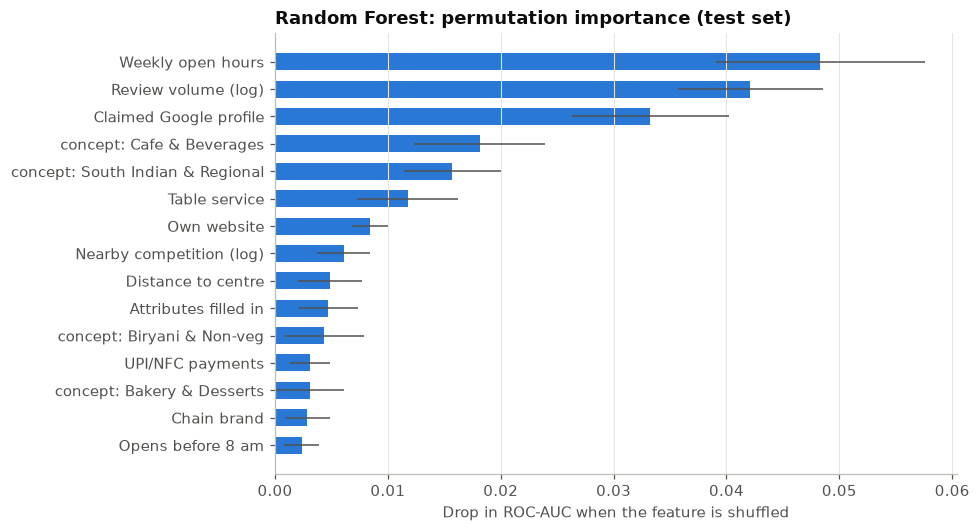

In [26]:
rf = best["Random Forest"]
pi = permutation_importance(rf, X_test, y_test, scoring="roc_auc", n_repeats=20, random_state=SEED, n_jobs=-1)
imp = pd.DataFrame({"mean": pi.importances_mean, "sd": pi.importances_std}, index=X.columns).sort_values("mean").tail(15)
imp["label"] = [LEVER_LABELS.get(c, c) for c in imp.index]
RESULTS["permutation_importance"] = imp[["label", "mean", "sd"]].iloc[::-1].round(4).reset_index(names="feature").to_dict("records")
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(imp["label"], imp["mean"], xerr=imp["sd"], color=BLUE, height=0.62, error_kw={"ecolor": INK2, "elinewidth": 1})
ax.grid(axis="y", visible=False)
ax.set(title="Random Forest: permutation importance (test set)", xlabel="Drop in ROC-AUC when the feature is shuffled")
save(fig, "12_permutation_importance")

The Random Forest does not assume linear effects, and it ranks much the same things at the top: weekly hours,
review volume, claimed profile, and the café and South Indian concepts. Table service and own website come next.
So the logistic regression result does not come only from its linear form.

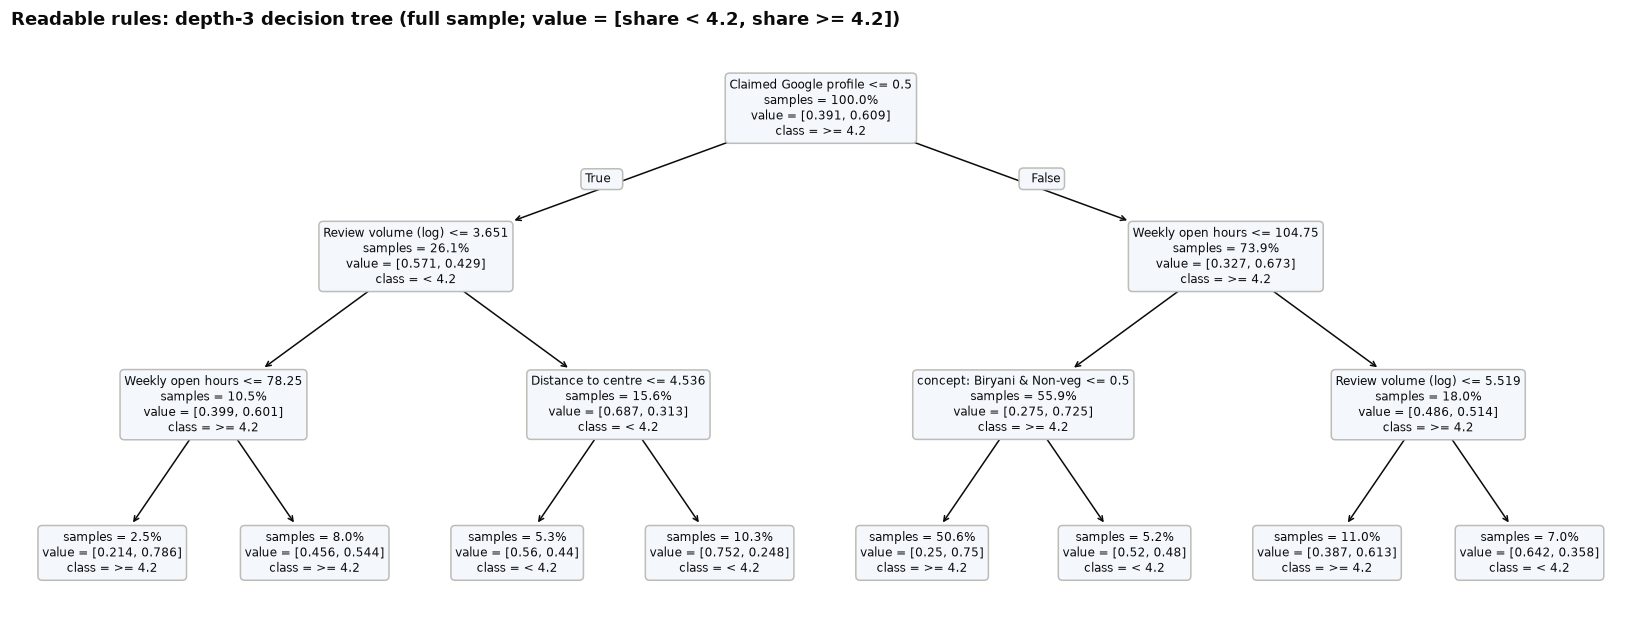

,rule,share_sample,success
0,not Claimed Google profile; <= 37 reviews; Wee...,0.025,0.786
1,Claimed Google profile; Weekly open hours <= 1...,0.506,0.750
2,Claimed Google profile; Weekly open hours > 10...,0.110,0.613
3,not Claimed Google profile; <= 37 reviews; Wee...,0.080,0.544
4,Claimed Google profile; Weekly open hours <= 1...,0.052,0.480
5,not Claimed Google profile; > 37 reviews; Dist...,0.053,0.440
6,Claimed Google profile; Weekly open hours > 10...,0.070,0.358
7,not Claimed Google profile; > 37 reviews; Dist...,0.103,0.248


In [27]:
# no class weights here, so the values in each box are the real shares
rules = DecisionTreeClassifier(max_depth=3, min_samples_leaf=60, random_state=SEED).fit(X, y)
names = [LEVER_LABELS.get(c, c) for c in X.columns]
fig, ax = plt.subplots(figsize=(19, 7))
plot_tree(rules, feature_names=names, class_names=["< 4.2", ">= 4.2"], filled=False, impurity=False,
          proportion=True, rounded=True, fontsize=8, ax=ax)
for t in ax.texts:
    t.set_bbox(dict(boxstyle="round,pad=0.35", facecolor="#f4f8fd", edgecolor=NEUTRAL))
ax.set_title("Readable rules: depth-3 decision tree (full sample; value = [share < 4.2, share >= 4.2])")
RESULTS["tree_rules"] = export_text(rules, feature_names=names, show_weights=False)
save(fig, "13_decision_rules")

# write each leaf of the tree out as a rule
t = rules.tree_
def condition(feat, thr, left):
    col, label = X.columns[feat], names[feat]
    if set(X[col].unique()) <= {0.0, 1.0}:
        return f"not {label}" if left else label
    if col == "log_reviews":
        return f"{'<=' if left else '>'} {np.expm1(thr):.0f} reviews"
    return f"{label} {'<=' if left else '>'} {thr:.1f}"
leaves = []
def walk(node, conds):
    if t.children_left[node] == -1:
        v = t.value[node][0]
        leaves.append({"rule": "; ".join(conds), "share_sample": t.n_node_samples[node] / t.n_node_samples[0],
                       "success": v[1] / v.sum()})
        return
    walk(t.children_left[node], conds + [condition(t.feature[node], t.threshold[node], True)])
    walk(t.children_right[node], conds + [condition(t.feature[node], t.threshold[node], False)])
walk(0, [])
RESULTS["tree_leaves"] = sorted(leaves, key=lambda l: -l["success"])
pd.DataFrame(RESULTS["tree_leaves"]).round(3)

The tree splits first on whether the profile is claimed: 67% of claimed venues reach 4.2 or higher, and 43% of
unclaimed ones do.

Two rules stand out. Claimed venues that are open about 105 hours a week or less and are not biryani/non-veg places
reach 4.2 in 75% of cases, and they are about half of all venues. Unclaimed venues with more than about 37 reviews
reach it only 31% of the time, and only 25% when they are more than about 4.5 km from the centre (44% within
4.5 km).

## 6. Robustness checks
1. Refit the logistic regression using venues with at least 5, 25 and 50 reviews.
2. Refit without the review-count control.
3. Run an OLS regression on the rating itself (HC3 standard errors) and see whether the directions agree.

In [28]:
g10 = f

def logit_or(g, drop=()):
    Xg = design(g).reindex(columns=X.columns, fill_value=0).drop(columns=list(drop))
    cont = [c for c in CONT if c not in drop]
    Xg[cont] = (Xg[cont] - Xg[cont].mean()) / Xg[cont].std()
    r = sm.Logit(g["high_rating"], sm.add_constant(Xg)).fit(disp=0, maxiter=500)
    return pd.DataFrame({"OR": np.exp(r.params), "p": r.pvalues}).drop("const")

KEY = coef[coef["p"] < 0.05].index.tolist()
rob = {}
for t in [5, 10, 25, 50]:
    g = engineer(live[live["reviews_count"] >= t])
    rob[f">= {t} reviews (n={len(g):,})"] = logit_or(g)["OR"]
rob["no review-volume control"] = logit_or(g10, drop=["log_reviews"])["OR"]
rob = pd.DataFrame(rob).loc[KEY]
rob.index = [coef.loc[k, "label"] for k in KEY]

# OLS on the continuous rating
Xo = sm.add_constant(Xs)
ols = sm.OLS(f["rating"], Xo).fit(cov_type="HC3")
agree = [(np.sign(ols.params[k]) == np.sign(logit.params[k])) for k in KEY]
RESULTS["robustness"] = {"table": rob.round(3).to_dict("index"), "ols_r2": float(ols.rsquared),
                         "sign_agreement": float(np.mean(agree)), "n_key": len(KEY),
                         "ols_significant_agree": int(sum((ols.pvalues[k] < 0.05) and a for k, a in zip(KEY, agree)))}
print(f"OLS on rating: R2 = {ols.rsquared:.3f}; sign agreement with the logit on {len(KEY)} significant levers = {np.mean(agree):.0%}")
rob.round(2)

OLS on rating: R2 = 0.252; sign agreement with the logit on 21 significant levers = 100%


,">= 5 reviews (n=3,813)",">= 10 reviews (n=3,412)",">= 25 reviews (n=2,675)",">= 50 reviews (n=2,157)",no review-volume control
Review volume (log),0.71,0.75,0.86,0.95,NaN
Weekly open hours,0.53,0.50,0.50,0.50,0.49
Distance to centre,0.92,0.91,0.93,0.91,0.91
Claimed Google profile,2.18,2.22,2.29,2.39,2.18
Own website,1.61,1.65,1.66,1.65,1.47
Menu link,1.77,1.86,1.89,1.80,1.87
Online ordering link,1.62,1.62,1.69,1.63,1.51
Attributes filled in,0.73,0.72,0.60,0.57,0.60
Table service,0.58,0.53,0.56,0.52,0.51
Wi-Fi,3.61,3.61,3.75,3.74,3.99


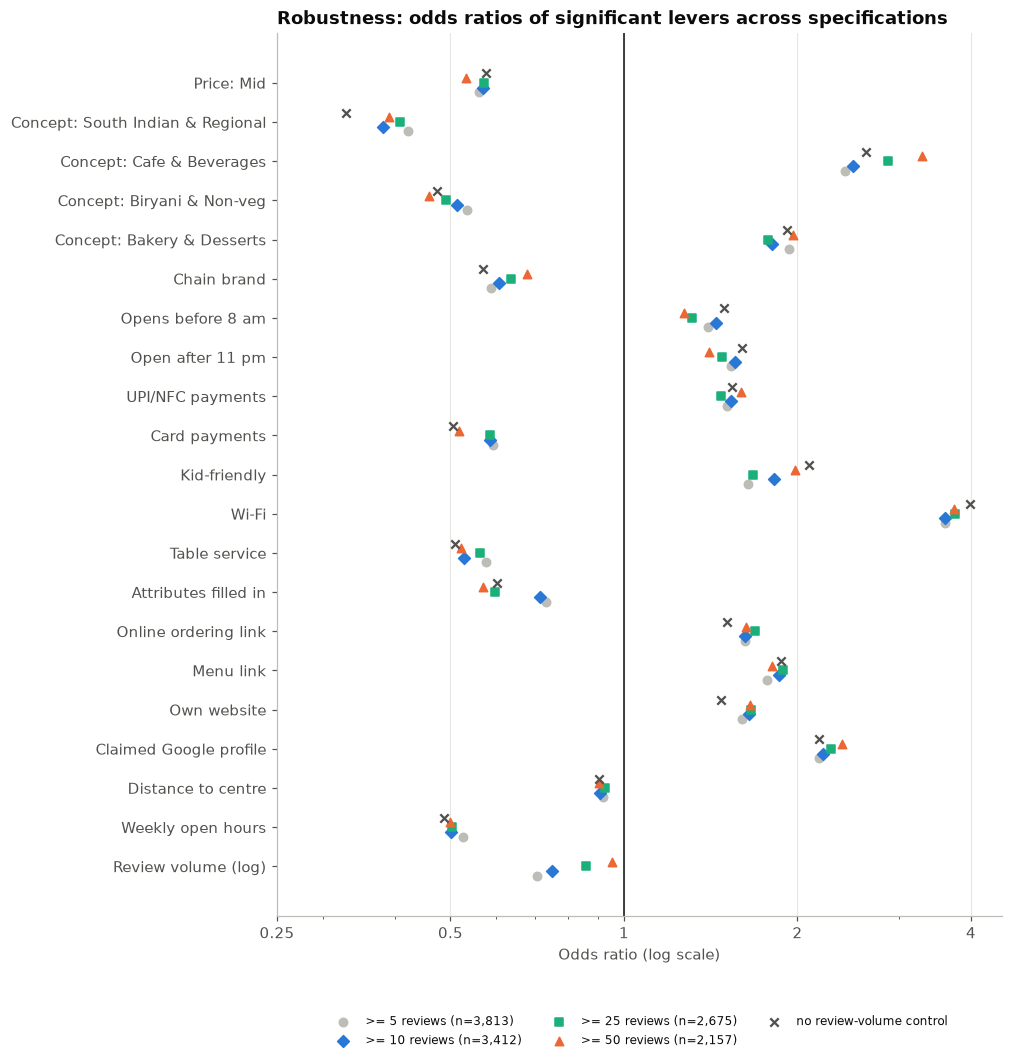

In [29]:
fig, ax = plt.subplots(figsize=(8.5, 0.42 * len(rob) + 1.6))
styles = list(zip(rob.columns, [NEUTRAL, BLUE, AQUA, ORANGE, INK2], ["o", "D", "s", "^", "x"]))
for k, (col, color, marker) in enumerate(styles):
    ax.scatter(rob[col], np.arange(len(rob)) + (k - 2) * 0.12, color=color, marker=marker, s=30, label=col, zorder=3)
ax.axvline(1, color=INK, lw=1)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4], ["0.25", "0.5", "1", "2", "4"])
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_yticks(np.arange(len(rob)), rob.index)
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=8)
ax.set(title="Robustness: odds ratios of significant levers across specifications", xlabel="Odds ratio (log scale)")
save(fig, "14_robustness")

The results are stable. Using venues with at least 5, 25 or 50 reviews barely changes the odds ratios (for the
claimed profile they stay between 2.2 and 2.4), and removing review count from the model leaves the main factors
pointing the same way. The OLS model on the actual rating (R² = 0.25) agrees in direction on all 21 significant
factors, and 20 of them are also significant there. So the conclusions do not depend on the 4.2 cut-off, the
10-review filter or the type of model.

## 7. Extra check: popular times
Google also shows how busy a place usually is at each hour ("popular times"). It is available for only about
a third of the venues. Five features were built from it: whether it is available, the highest busyness, the
share of busyness after 6 pm, the weekend uplift over weekdays and the number of busy hours (busyness of 50 or more).

The question is whether adding them improves the models. Each model keeps the settings found in Section 4 and is
scored with the same 5-fold cross-validation repeated 3 times, with and without the new features.

In [30]:
def popular_times_features(v):
    none = dict(has_popular_times=0, peak_busyness=0.0, evening_share=0.0, weekend_uplift=0.0, busy_hours=0.0)
    if not isinstance(v, str):
        return none
    days = {d: np.array([h.get(str(k), 0) for k in range(6, 24)], float) for d, h in json.loads(v).items() if h}
    if not days:
        return none
    grid = np.vstack(list(days.values()))                       # one row per weekday, hours 6 to 23
    weekend = np.mean([days[d].sum() for d in days if d in ("Saturday", "Sunday")] or [0])
    weekday = np.mean([days[d].sum() for d in days if d not in ("Saturday", "Sunday")] or [0])
    return dict(has_popular_times=1, peak_busyness=grid.max() / 100,
                evening_share=grid[:, 12:].sum() / grid.sum() if grid.sum() else 0.0,
                weekend_uplift=weekend / weekday - 1 if weekday else 0.0,
                busy_hours=(grid >= 50).sum(axis=1).mean())

pt = pd.DataFrame(f["popular_times"].apply(popular_times_features).tolist(), index=f.index)
pt_cont = ["peak_busyness", "evening_share", "weekend_uplift", "busy_hours"]
X_pt = pd.concat([X, pt], axis=1)

def refit_scaler(model, cols):
    m = clone(model)
    if "scale" in m.named_steps:
        m.set_params(scale=ColumnTransformer([("num", StandardScaler(), cols)], remainder="passthrough"))
    return m

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
pt_check = {}
for name, model in best.items():
    without = cross_val_score(clone(model), X, y, cv=rcv, scoring="roc_auc", n_jobs=-1).mean()
    with_pt = cross_val_score(refit_scaler(model, CONT + pt_cont), X_pt, y, cv=rcv, scoring="roc_auc", n_jobs=-1).mean()
    pt_check[name] = {"without": round(without, 4), "with": round(with_pt, 4), "change": round(with_pt - without, 4)}
RESULTS["popular_times_check"] = {"available_share": float(pt["has_popular_times"].mean()), "auc": pt_check}
print(f"popular times available for {pt['has_popular_times'].mean():.0%} of the modelled venues")
pd.DataFrame(pt_check).T

popular times available for 35% of the modelled venues


,without,with,change
Logistic Regression,0.7697,0.7687,-0.0011
Decision Tree,0.7173,0.7162,-0.0011
KNN,0.7612,0.7471,-0.0141
Random Forest,0.7850,0.7832,-0.0018


The popular-times features do not help. Cross-validated ROC-AUC changes by -0.001 for Logistic Regression and the
Decision Tree, -0.002 for Random Forest and -0.014 for KNN. KNN gets worse because five extra columns, most of
them empty for the two thirds of venues without the data, add noise to its distance calculation. The features are
also only weakly related to the target (correlation of about -0.08 with reaching 4.2), possibly because busy places
tend to have many reviews, which the models already capture through the review count. Popular times are therefore
left out of the final models. They also describe how busy a place is, not something an owner can change.

## 8. Recommendations
Each factor an owner can change is scored on its marginal effect, its significance, how common it already is
(adoption) and a rough effort rating (Low, Medium or High) based on judgement.

Concept, chain status, location and number of reviews cannot really be changed by an existing venue, so they
are treated as controls and not as recommendations.

In [31]:
EFFORT = {
    "is_claimed": "Low", "own_website": "Medium", "social_page_only": "Low", "has_phone": "Low",
    "has_menu_link": "Low", "online_ordering": "Medium", "has_attributes": "Low", "table_service": "High",
    "delivery": "Medium", "takes_reservations": "Low", "restroom": "High", "wifi": "Low", "free_parking": "High",
    "kid_friendly": "Medium", "outdoor_seating": "High", "wheelchair_access": "Medium", "card_payments": "Low",
    "digital_payments": "Low", "open_late": "Medium", "opens_early": "Medium", "has_hours": "Low",
}
LEVERS = list(EFFORT)
sc = me.loc[LEVERS, ["label", "AME_pp", "low_pp", "high_pp", "p"]].copy()
sc["adoption"] = [X[c].mean() for c in LEVERS]
sc["effort"] = [EFFORT[c] for c in LEVERS]
def verdict(r):
    if r.p >= 0.05:
        return "No clear evidence"
    if r.AME_pp > 0 and r.adoption < 0.06:
        return "Promising (thin evidence)"   # very few venues have it
    if r.AME_pp > 0:
        return "Prioritise" if r.effort == "Low" else "Consider"
    return "Negative marker"
sc["verdict"] = sc.apply(verdict, axis=1)
sc = sc.sort_values(["verdict", "AME_pp"], ascending=[True, False])
RESULTS["scorecard"] = sc.round(4).reset_index(names="feature").to_dict("records")
sc.assign(adoption=lambda d: (d.adoption * 100).round(0)).round(2)

,label,AME_pp,low_pp,high_pp,p,adoption,effort,verdict
kid_friendly,Kid-friendly,10.67,5.56,15.79,0.00,33.0,Medium,Consider
own_website,Own website,9.00,4.87,13.13,0.00,22.0,Medium,Consider
online_ordering,Online ordering link,8.64,1.28,16.00,0.02,13.0,Medium,Consider
open_late,Open after 11 pm,7.90,3.76,12.05,0.00,17.0,Medium,Consider
opens_early,Opens before 8 am,6.57,2.19,10.95,0.00,31.0,Medium,Consider
has_attributes,Attributes filled in,-6.14,-10.18,-2.09,0.00,67.0,Low,Negative marker
card_payments,Card payments,-10.02,-16.33,-3.71,0.00,22.0,Low,Negative marker
table_service,Table service,-12.24,-18.00,-6.47,0.00,22.0,High,Negative marker
social_page_only,Social page as website,7.91,-0.07,15.88,0.05,4.0,Low,No clear evidence
wheelchair_access,Wheelchair access,6.37,-0.22,12.96,0.06,5.0,Medium,No clear evidence


In [32]:
# what-if for one factor at a time: venues without it, predicted chance of 4.2+ before and after switching it on
rows = []
for c in [c for c in LEVERS if me.loc[c, "p"] < 0.05 and me.loc[c, "AME"] > 0]:
    lacking = X[c] == 0
    Xb = sm.add_constant(Xs)[lacking]
    Xa = Xb.copy(); Xa[c] = 1
    pb, pa = logit.predict(Xb), logit.predict(Xa)
    rows.append({"lever": LEVER_LABELS[c], "effort": EFFORT[c], "venues_without": int(lacking.sum()),
                 "p_before": pb.mean(), "p_after": pa.mean(), "uplift_pp": (pa.mean() - pb.mean()) * 100})
what_if = pd.DataFrame(rows).sort_values("uplift_pp", ascending=False)
RESULTS["what_if"] = what_if.round(4).to_dict("records")
what_if.round(3)

,lever,effort,venues_without,p_before,p_after,uplift_pp
4,Wi-Fi,Low,3297,0.601,0.806,20.554
0,Claimed Google profile,Low,891,0.429,0.591,16.192
2,Menu link,Low,3252,0.601,0.710,10.867
5,Kid-friendly,Medium,2303,0.606,0.713,10.767
1,Own website,Medium,2678,0.584,0.674,8.981
3,Online ordering link,Medium,2982,0.600,0.686,8.627
7,Open after 11 pm,Medium,2842,0.610,0.689,7.844
6,UPI/NFC payments,Low,2339,0.604,0.682,7.769
8,Opens before 8 am,Medium,2360,0.653,0.716,6.288


The table above shows the model's estimate for each factor on its own. These are associations and they are
probably an upper limit on what a single change would do.

* Claiming the Google profile has the best evidence and costs nothing. 891 venues in the sample (26%) have not done
  it, and for them the predicted chance of reaching 4.2 goes from 43% to 59% (+16 points).
* UPI/NFC payments are also well supported (31% of venues already have them), at about +8 points.
* Wi-Fi (+21 points) and a menu link (+11) look strong, but very few venues have them, so the estimates are
  uncertain. They may only show that a place is a laptop-friendly café or has a well-organised owner.
* Options that need more effort are an own website (+9), online ordering (+9), kid-friendly facilities (+11), and
  adding breakfast or late-night hours without making the whole day longer.

In [33]:
os.makedirs("outputs", exist_ok=True)
def to_py(o):
    if isinstance(o, dict): return {str(k): to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [to_py(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return None if np.isnan(o) else float(o)
    if isinstance(o, float) and np.isnan(o): return None
    return o
with open("outputs/results.json", "w") as fh:
    json.dump(to_py(RESULTS), fh, indent=2, default=str)
print("saved outputs/results.json with", len(RESULTS), "sections")

saved outputs/results.json with 28 sections


## 9. Limitations
* These are associations. For example, a claimed profile and a good rating could both come from an owner who cares.
* The data is a single snapshot. Ratings and profiles change over time.
* Google Maps shows about 120 results per search, so coverage depends on the keyword and locality list. Very small
  places that are not on Google Maps are missing.
* Some attributes are added by users. A missing attribute may mean "not reported" and not "not offered". The
  `has_attributes` flag is there to partly deal with this.
* The closed flag comes from the scraper's status field (59 venues) and was not checked separately.